In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


In [3]:
data_path="C:/Users/nasser.mohamed/Desktop/prediction/DATA.xlsx"


In [4]:
data=pd.read_excel(data_path)
data

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-29,13,2022,12,52,21999609.63,250212,NaN,NaN,NaN,NaN,5.707951e+07
1,2023-01-05,13,2023,1,1,57079507.90,561149,21999609.63,250212.0,NaN,NaN,8.810620e+07
2,2023-01-12,13,2023,1,2,88106203.78,558334,57079507.90,561149.0,21999609.63,250212.0,8.719238e+07
3,2023-01-19,13,2023,1,3,87192375.60,572045,88106203.78,558334.0,57079507.90,561149.0,6.996805e+07
4,2023-01-26,13,2023,1,4,69968045.26,583024,87192375.60,572045.0,88106203.78,558334.0,1.074685e+08
...,...,...,...,...,...,...,...,...,...,...,...,...
503,2025-05-01,16,2025,5,18,19107157.80,124223,17246950.67,116842.0,16729392.74,116027.0,1.574262e+07
504,2025-05-08,16,2025,5,19,15742619.36,105028,19107157.80,124223.0,17246950.67,116842.0,1.555092e+07
505,2025-05-15,16,2025,5,20,15550919.01,108547,15742619.36,105028.0,19107157.80,124223.0,1.643832e+07
506,2025-05-22,16,2025,5,21,16438319.18,115906,15550919.01,108547.0,15742619.36,105028.0,3.196738e+06


In [5]:
df = data.fillna(data.mean(numeric_only=True))

In [6]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-29,13,2022,12,52,21999609.63,250212,3.287755e+07,346677.46627,3.286940e+07,346796.352,5.707951e+07
1,2023-01-05,13,2023,1,1,57079507.90,561149,2.199961e+07,250212.00000,3.286940e+07,346796.352,8.810620e+07
2,2023-01-12,13,2023,1,2,88106203.78,558334,5.707951e+07,561149.00000,2.199961e+07,250212.000,8.719238e+07
3,2023-01-19,13,2023,1,3,87192375.60,572045,8.810620e+07,558334.00000,5.707951e+07,561149.000,6.996805e+07
4,2023-01-26,13,2023,1,4,69968045.26,583024,8.719238e+07,572045.00000,8.810620e+07,558334.000,1.074685e+08
...,...,...,...,...,...,...,...,...,...,...,...,...
503,2025-05-01,16,2025,5,18,19107157.80,124223,1.724695e+07,116842.00000,1.672939e+07,116027.000,1.574262e+07
504,2025-05-08,16,2025,5,19,15742619.36,105028,1.910716e+07,124223.00000,1.724695e+07,116842.000,1.555092e+07
505,2025-05-15,16,2025,5,20,15550919.01,108547,1.574262e+07,105028.00000,1.910716e+07,124223.000,1.643832e+07
506,2025-05-22,16,2025,5,21,16438319.18,115906,1.555092e+07,108547.00000,1.574262e+07,105028.000,3.196738e+06


In [7]:
column=["TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","NEXT_WEEK_TOTAL_AMOUNT"]

In [8]:
for col in column:
    df[col] = df[col].astype(float).astype(int)

In [9]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-29,13,2022,12,52,21999609,250212,32877548,346677,32869403,346796,57079507
1,2023-01-05,13,2023,1,1,57079507,561149,21999609,250212,32869403,346796,88106203
2,2023-01-12,13,2023,1,2,88106203,558334,57079507,561149,21999609,250212,87192375
3,2023-01-19,13,2023,1,3,87192375,572045,88106203,558334,57079507,561149,69968045
4,2023-01-26,13,2023,1,4,69968045,583024,87192375,572045,88106203,558334,107468479
...,...,...,...,...,...,...,...,...,...,...,...,...
503,2025-05-01,16,2025,5,18,19107157,124223,17246950,116842,16729392,116027,15742619
504,2025-05-08,16,2025,5,19,15742619,105028,19107157,124223,17246950,116842,15550919
505,2025-05-15,16,2025,5,20,15550919,108547,15742619,105028,19107157,124223,16438319
506,2025-05-22,16,2025,5,21,16438319,115906,15550919,108547,15742619,105028,3196738


In [10]:
df['RATIO_TOTAL_LAST_WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_WEEK_TOTAL_AMOUNT']
df['RATIO_TOTAL_LAST_2WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_2WEEK_TOTAL_AMOUNT']
df['RATIO_TRANS_LAST_WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_WEEK_TRANSACTION_COUNT']
df['RATIO_TRANS_LAST_2WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_2WEEK_TRANSACTION_COUNT']

In [11]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
0,2022-12-29,13,2022,12,52,21999609,250212,32877548,346677,32869403,346796,57079507,0.669138,0.669304,0.721744,0.721496
1,2023-01-05,13,2023,1,1,57079507,561149,21999609,250212,32869403,346796,88106203,2.594569,1.736554,2.242694,1.618095
2,2023-01-12,13,2023,1,2,88106203,558334,57079507,561149,21999609,250212,87192375,1.543570,4.004899,0.994984,2.231444
3,2023-01-19,13,2023,1,3,87192375,572045,88106203,558334,57079507,561149,69968045,0.989628,1.527560,1.024557,1.019417
4,2023-01-26,13,2023,1,4,69968045,583024,87192375,572045,88106203,558334,107468479,0.802456,0.794133,1.019193,1.044221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503,2025-05-01,16,2025,5,18,19107157,124223,17246950,116842,16729392,116027,15742619,1.107857,1.142131,1.063171,1.070639
504,2025-05-08,16,2025,5,19,15742619,105028,19107157,124223,17246950,116842,15550919,0.823912,0.912777,0.845480,0.898889
505,2025-05-15,16,2025,5,20,15550919,108547,15742619,105028,19107157,124223,16438319,0.987823,0.813879,1.033505,0.873808
506,2025-05-22,16,2025,5,21,16438319,115906,15550919,108547,15742619,105028,3196738,1.057064,1.044192,1.067796,1.103572


In [12]:
df.set_index('WEEK_START', inplace=True)

In [13]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-29,13,2022,12,52,21999609,250212,32877548,346677,32869403,346796,57079507,0.669138,0.669304,0.721744,0.721496
2023-01-05,13,2023,1,1,57079507,561149,21999609,250212,32869403,346796,88106203,2.594569,1.736554,2.242694,1.618095
2023-01-12,13,2023,1,2,88106203,558334,57079507,561149,21999609,250212,87192375,1.543570,4.004899,0.994984,2.231444
2023-01-19,13,2023,1,3,87192375,572045,88106203,558334,57079507,561149,69968045,0.989628,1.527560,1.024557,1.019417
2023-01-26,13,2023,1,4,69968045,583024,87192375,572045,88106203,558334,107468479,0.802456,0.794133,1.019193,1.044221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-01,16,2025,5,18,19107157,124223,17246950,116842,16729392,116027,15742619,1.107857,1.142131,1.063171,1.070639
2025-05-08,16,2025,5,19,15742619,105028,19107157,124223,17246950,116842,15550919,0.823912,0.912777,0.845480,0.898889
2025-05-15,16,2025,5,20,15550919,108547,15742619,105028,19107157,124223,16438319,0.987823,0.813879,1.033505,0.873808


In [14]:
split_date='2025-05-29'
df = df[df.index < split_date]

In [15]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-29,13,2022,12,52,21999609,250212,32877548,346677,32869403,346796,57079507,0.669138,0.669304,0.721744,0.721496
2023-01-05,13,2023,1,1,57079507,561149,21999609,250212,32869403,346796,88106203,2.594569,1.736554,2.242694,1.618095
2023-01-12,13,2023,1,2,88106203,558334,57079507,561149,21999609,250212,87192375,1.543570,4.004899,0.994984,2.231444
2023-01-19,13,2023,1,3,87192375,572045,88106203,558334,57079507,561149,69968045,0.989628,1.527560,1.024557,1.019417
2023-01-26,13,2023,1,4,69968045,583024,87192375,572045,88106203,558334,107468479,0.802456,0.794133,1.019193,1.044221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-24,16,2025,4,17,17246950,116842,16729392,116027,16219241,111547,19107157,1.030937,1.063364,1.007024,1.047469
2025-05-01,16,2025,5,18,19107157,124223,17246950,116842,16729392,116027,15742619,1.107857,1.142131,1.063171,1.070639
2025-05-08,16,2025,5,19,15742619,105028,19107157,124223,17246950,116842,15550919,0.823912,0.912777,0.845480,0.898889


In [16]:
split_date='2025-05-01'
train_df = df[df.index < split_date]
test_df = df[df.index >= split_date]

In [17]:
test_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2025-05-01,13,2025,5,18,53511261,10966,64095644,12272,58991491,11044,75072480,0.834866,0.907101,0.893579,0.992937
2025-05-08,13,2025,5,19,75072480,13478,53511261,10966,64095644,12272,78225816,1.402929,1.171257,1.229072,1.098272
2025-05-15,13,2025,5,20,78225816,13809,75072480,13478,53511261,10966,87388684,1.042004,1.461857,1.024559,1.259256
2025-05-22,13,2025,5,21,87388684,15198,78225816,13809,75072480,13478,23478363,1.117134,1.164058,1.100587,1.127615
2025-05-01,14,2025,5,18,11804251,428771,11773816,435340,11234744,417078,11275732,1.002585,1.050692,0.984911,1.028036
2025-05-08,14,2025,5,19,11275732,420593,11804251,428771,11773816,435340,10808886,0.955226,0.957696,0.980927,0.966125
2025-05-15,14,2025,5,20,10808886,405479,11275732,420593,11804251,428771,11440391,0.958597,0.915677,0.964065,0.945677
2025-05-22,14,2025,5,21,11440391,418121,10808886,405479,11275732,420593,2723173,1.058425,1.014603,1.031178,0.994123
2025-05-01,15,2025,5,18,20431618,766249,20739499,802069,19012204,748463,20190841,0.985155,1.074658,0.955341,1.023763


In [18]:
features=["MAIN_BILLER_ID","YEAR","MONTH","WEEK_NUMBER","TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","RATIO_TOTAL_LAST_WEEK","RATIO_TOTAL_LAST_2WEEK","RATIO_TRANS_LAST_WEEK","RATIO_TRANS_LAST_2WEEK"]
pred="NEXT_WEEK_TOTAL_AMOUNT"

In [19]:
X_train = train_df[features]   # features
y_train = train_df[pred]    # target

X_test = test_df[features]
y_test = test_df[pred]    

In [20]:
X_train


,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,
2022-12-29,13,2022,12,52,21999609,250212,32877548,346677,32869403,346796,0.669138,0.669304,0.721744,0.721496
2023-01-05,13,2023,1,1,57079507,561149,21999609,250212,32869403,346796,2.594569,1.736554,2.242694,1.618095
2023-01-12,13,2023,1,2,88106203,558334,57079507,561149,21999609,250212,1.543570,4.004899,0.994984,2.231444
2023-01-19,13,2023,1,3,87192375,572045,88106203,558334,57079507,561149,0.989628,1.527560,1.024557,1.019417
2023-01-26,13,2023,1,4,69968045,583024,87192375,572045,88106203,558334,0.802456,0.794133,1.019193,1.044221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-27,16,2025,3,13,20295842,126032,15587680,99116,14278478,101198,1.302044,1.421429,1.271561,1.245400
2025-04-03,16,2025,4,14,16499528,114393,20295842,126032,15587680,99116,0.812951,1.058498,0.907650,1.154133
2025-04-10,16,2025,4,15,16219241,111547,16499528,114393,20295842,126032,0.983012,0.799141,0.975121,0.885069


## model

In [21]:
model =XGBRegressor(
    objective='reg:squarederror',  # regression objective
    n_estimators=3000,              # number of trees
    learning_rate=0.1,             # step size shrinkage
    max_depth=8,                   # maximum tree depth
    subsample=0.8,                 # % of data used per tree
    colsample_bytree=0.8,          # % of features used per tree
    reg_alpha=0.1,                 # L1 regularization term
    reg_lambda=1,                  # L2 regularization term
    random_state=42                # for reproducibility
)

# Fit the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=None, num_parallel_tree=None, ...)

[13] lengths - X_test: 4, y_true: 4, y_pred: 4
[13] MSE: 1131171739832758.25


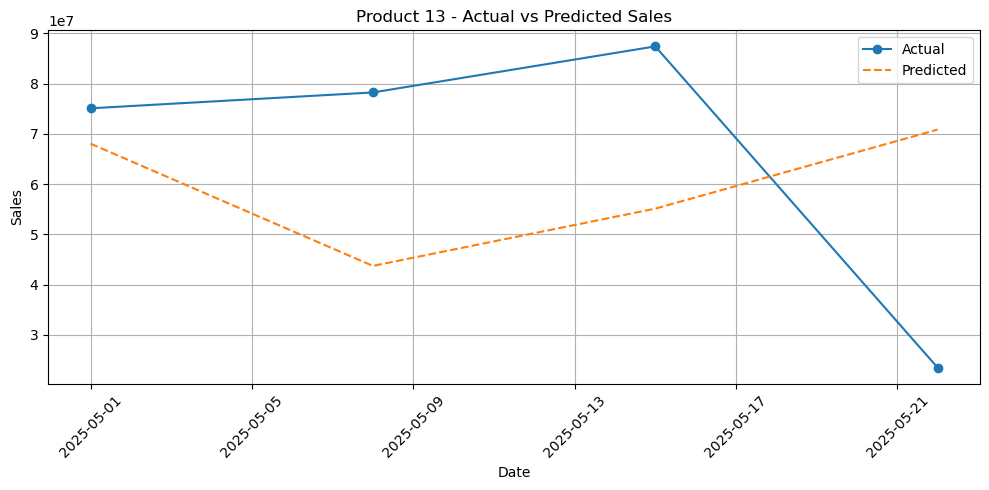

[14] lengths - X_test: 4, y_true: 4, y_pred: 4
[14] MSE: 20686594911168.25


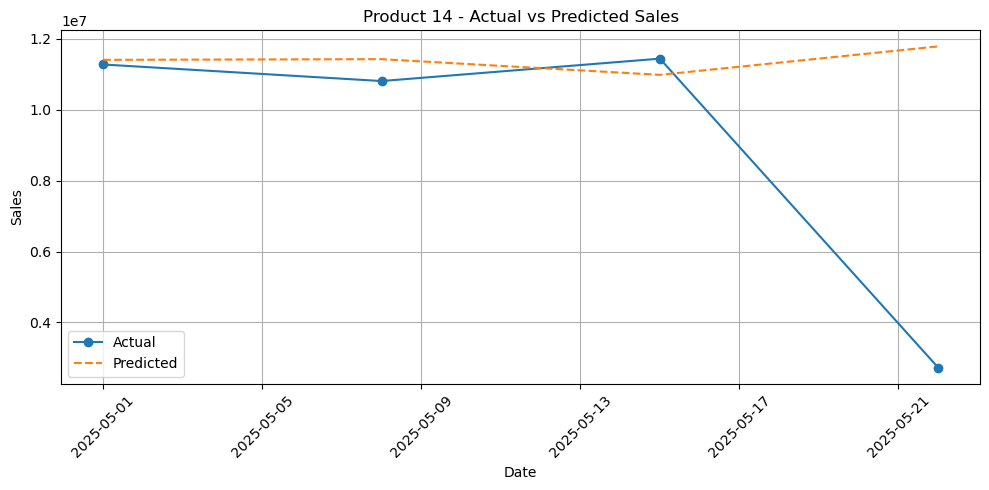

[15] lengths - X_test: 4, y_true: 4, y_pred: 4
[15] MSE: 56162681600455.50


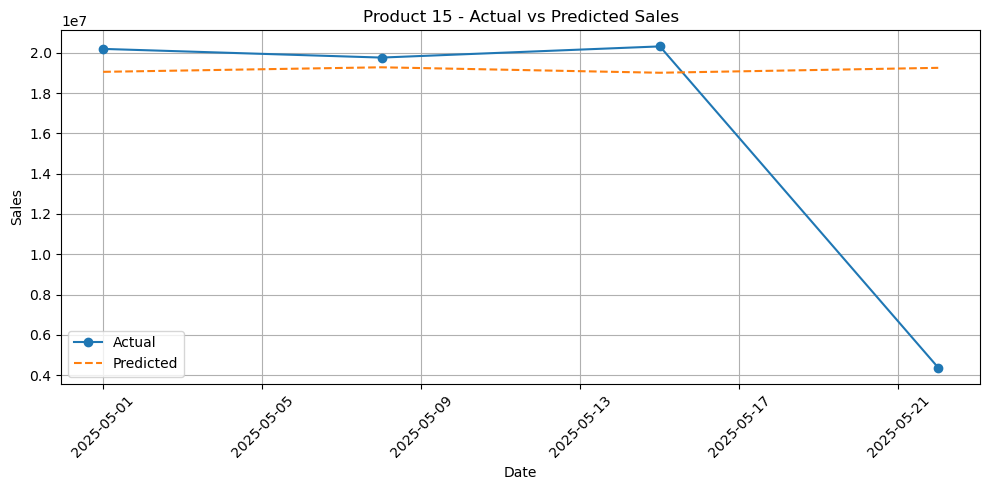

[16] lengths - X_test: 4, y_true: 4, y_pred: 4
[16] MSE: 49204682208875.25


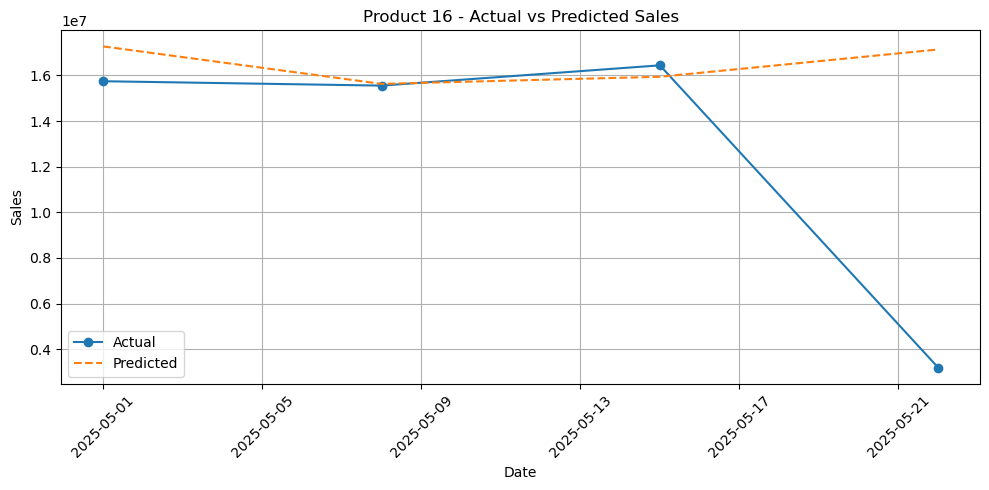

In [22]:
all_actuals = []
all_preds = []

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    # Sort by date (index) and drop rows with NaNs in features or target
    group = group.sort_index()
    group = group.dropna(subset=features + [pred])  # ensure no missing values
    
    # Prepare feature matrix and true target values
    X_test = group[features]
    y_test = group[pred]
    
    # Predict using the global model
    y_pred = model.predict(X_test)
    # Flatten arrays if needed (usually y_pred is already 1D)
    y_pred = y_pred.flatten()
    y_true = y_test.values.flatten()
    all_actuals.extend(y_true)
    all_preds.extend(y_pred)
    # Check lengths (debug)
    print(f"[{product}] lengths - X_test: {len(X_test)}, y_true: {len(y_true)}, y_pred: {len(y_pred)}")
    
    # Calculate MSE for this product
    mse = mean_squared_error(y_true, y_pred)
    print(f"[{product}] MSE: {mse:.2f}")
    
    # Plot actual vs predicted sales over time for this product
    plt.figure(figsize=(10,5))
    plt.plot(group.index, y_true, label='Actual', marker='o')
    plt.plot(group.index, y_pred, label='Predicted', linestyle='--')
    plt.title(f"Product {product} - Actual vs Predicted Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
y_pred

array([41451752. , 49842368. , 57335908. , 61212056. , 11063902. ,
       10768595. , 11601870. ,  5883332. , 19079966. , 19428496. ,
       19408110. ,  7360177.5, 17306692. , 16576975. , 17556552. ,
        6639062. ], dtype=float32)

In [ ]:
all_actuals

[75072480,
 78225816,
 87388684,
 23478363,
 11275732,
 10808886,
 11440391,
 2723173,
 20190841,
 19760576,
 20315246,
 4371505,
 15742619,
 15550919,
 16438319,
 3196738]